In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from joblib import Parallel, delayed
from datetime import datetime
import sys
from pathlib import Path

import sys
# sys.path.append("../src")
sys.path.append(str(Path.cwd().parent))

# from indicators.indicators import load_symbol, build_indicators
from mdt.mdt import load_symbol
from backtester import engine

import vars

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_colwidth', 200)

color_back = "#0d1117"

path_repo = vars.path_repo
path_data = vars.path_data

In [2]:
symbs = vars.symbs

symbs_crypto = [x for x in symbs if "-USD" in x]
symbs_forex = [x for x in symbs if "=X" in x]
symbs_stocks = [x for x in symbs if x not in symbs_crypto + symbs_forex]

print("Total:", len(symbs))
print("Crypto :", len(symbs_crypto), f"({(len(symbs_crypto)/len(symbs))*100:.0f}%)")
print("Forex:", len(symbs_forex), f"({(len(symbs_forex)/len(symbs))*100:.0f}%)")
print("Stocks:", len(symbs_stocks), f"({(len(symbs_stocks)/len(symbs))*100:.0f}%)")

Total: 12
Crypto : 3 (25%)
Forex: 3 (25%)
Stocks: 6 (50%)


In [3]:
symb = "AAPL"
df = load_symbol(symb, "1h", 400) 
df

Price,Close,High,Low,Open,Volume,date,EMA20,EMA50,EMA200,RSI,MACD,MACD_signal,MACD_hist,BB_upper,BB_mid,BB_lower,BB_position,STOCH_K,STOCH_D,ATR,OBV,OBV_EMA,ADX,ADX+DI,ADX-DI,prev26,prev52,VPVMA,VPVMAS,VWAP,spread,vol_ma,volume_ma,volume_increasing,order_flow,volatility,CMF,PSAR,WillR,Donchian_high,Donchian_low,ema50_distance,MACD_bearish_div,MACD_bullish_div,sign_macd_rsi_robust,sign_macd_rsi_simple,sign_macd_rsi_simple_break,sign_macd_rsi_simple_bb_pos,sign_macd_rsi_bb,sign_macd_rsi_bb_ema,ind_adx,sign_adx_crec,sign_adx_crec_rsi,sign_adx_rsi,sign_adx_rsi_robust,sign_adx_rsi_xtrem,sign_vpvma,sign_sinergia,sign_rsi_bb_rever,sign_ma_macd,str_squ_kel_bb,sign_gold,ind_3ema,sign_rsi30,sign_rsi20,sign_rsi15,trend_adx,sign_pullb_ema,sign_rsi_div,ind_vwap_deviation,sign_supo_resi,ind_volume_anomaly,ind_compress_range,sign_sobreextema,sign_stochastic,sign_cmf,sign_elderray,sign_willr,sign_donchian,sign_liquidsweep,sign_macd_div1,sign_macd_div3,sign_macd_div5,sign_random,sign_random2,sign_random3
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-04-28 16:30:00+00:00,208.139999,208.729996,207.850006,207.850006,2227932,2025-04-28 16:30:00+00:00,206.830227,203.372700,206.634457,59.648300,1.884573,2.220818,-0.336245,210.279038,207.345994,204.412950,0.635355,30.192753,42.269301,1.895274,-89893340.0,-8.692587e+07,32.981381,28.138171,14.494835,198.620193,197.070007,-16.475237,-11.504842,208.469796,0.004228,4437690.05,4437690.05,False,buy,0.004161,-0.054225,211.338400,-63.396201,211.500000,202.940002,0.023441,False,False,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025-04-28 17:30:00+00:00,209.869995,210.050003,208.080002,208.134995,3099461,2025-04-28 17:30:00+00:00,207.119729,203.627496,206.666652,64.766531,1.904981,2.157651,-0.252670,210.329631,207.638994,204.948357,0.914586,39.364009,35.575492,1.900612,-86793879.0,-8.691330e+07,33.453631,31.015759,13.421690,199.660004,198.350098,-9.313539,-11.522894,208.674888,0.009387,4413305.40,4413305.40,False,buy,0.004401,-0.004163,211.183265,-30.754791,211.500000,202.940002,0.030656,False,False,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2.0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,1,0,0
2025-04-28 18:30:00+00:00,210.539993,210.940002,209.761398,209.869995,2610842,2025-04-28 18:30:00+00:00,207.445468,203.898574,206.705193,66.536798,1.952708,2.116662,-0.163954,210.467064,207.947993,205.428923,1.014475,55.955459,41.837407,1.849040,-84183037.0,-8.665327e+07,34.215679,33.041699,12.810607,206.804993,196.910004,-12.137233,-11.381942,208.879734,0.005598,4272644.05,4272644.05,False,buy,0.004419,0.024497,211.034334,-18.113324,211.500000,202.940002,0.032572,False,False,0,0,0,0,0,0,1,1,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,2.0,0,0,0,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0
2025-04-28 19:30:00+00:00,210.089996,211.499802,210.039993,210.529999,3584738,2025-04-28 19:30:00+00:00,207.697328,204.141375,206.738872,64.203538,1.931951,2.079720,-0.147769,210.706332,208.136493,205.566654,0.880083,67.462263,54.260577,1.821238,-87767775.0,-8.675942e+07,35.116214,33.345471,12.077156,204.630005,197.759995,-12.219262,-11.651056,209.038327,0.006948,4029997.85,4029997.85,False,sell,0.004051,-0.118300,207.460007,-26.603827,211.500000,205.220093,0.029140,False,False,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0,0,0,0,0,0,0,0,-1,0,-1,0,0,0,0,0,0,0,0
2025-04-29 13:30:00+00:00,210.949997,212.240005,208.369995,208.692993,9190515,2025-04-29 13:30:00+00:00,208.007106,204.408380,206.780774,66.613167,1.962276,2.056231,-0.093955,211.028792,208.387743,205.746693,0.985083,71.622180,65.013301,1.967579,-78577260.0,-8.598016e+07,34.542778,28.660695,16.442968,204.110001,194.554993,7.640220,-8.865954,210.949997,0.018346,4276382.70,4276382.70,True,buy,0.004053,-0.074624,207.540803,-22.532876,212.240005,205.580093,0.032003,False,False,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0,0,0,0,1,0,-1,0,0,-1,0,0,-1,0,0,0,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [31]:
# cols_sign = [col for col in df.columns if col.startswith("sign_")] 
# cols_indic = [col for col in df.columns if not col.startswith("sign_")] 

cols_sign = [
'sign_random', 'sign_random2', 
'sign_macd_rsi_robust', 'sign_macd_rsi_simple', #'sign_macd_rsi_simple_break', #'sign_macd_rsi_simple_bb_pos', 'sign_macd_rsi_bb', 'sign_macd_rsi_bb_ema', 
'sign_adx_crec', 'sign_adx_crec_rsi', #'sign_adx_rsi', 'sign_adx_rsi_robust', #'sign_adx_rsi_xtrem', 
'sign_vpvma', 'sign_sinergia', #'sign_rsi_bb_rever', #'sign_ma_macd', 'str_squ_kel_bb', 
'sign_gold', 
'sign_rsi30', #'sign_rsi20', 'sign_rsi15', 'sign_pullb_ema', 'sign_rsi_div', 'sign_supo_resi', 'sign_sobreextema', 'sign_stochastic', 'sign_cmf', 'sign_elderray', 
# 'sign_willr', 'sign_donchian', 'sign_liquidsweep', 'sign_macd_div1', 'sign_macd_div3', 'sign_macd_div5', 'sign_random3'
]

cols_sign = [
'sign_random', 'sign_random2', 'sign_macd_rsi_robust', 'sign_macd_rsi_simple', 'sign_macd_rsi_simple_break', 'sign_macd_rsi_simple_bb_pos', 'sign_macd_rsi_bb', 'sign_macd_rsi_bb_ema', 
'sign_adx_crec', 'sign_adx_crec_rsi', 'sign_adx_rsi', 'sign_adx_rsi_robust', 'sign_adx_rsi_xtrem', 'sign_vpvma', 'sign_sinergia', 'sign_rsi_bb_rever', 'sign_ma_macd', 'str_squ_kel_bb', 
'sign_gold', 'sign_rsi30', 'sign_rsi20', 'sign_rsi15', 'sign_pullb_ema', 'sign_rsi_div', 'sign_supo_resi', 'sign_sobreextema', 'sign_stochastic', 'sign_cmf', 'sign_elderray', 
'sign_willr', 'sign_donchian', 'sign_liquidsweep', 'sign_macd_div1', 'sign_macd_div3', 'sign_macd_div5', 'sign_random3'
]

cols_indic = [
'Close', 'High', 'Low', 'Open', 'Volume', 'date', 'EMA20', 'EMA50', 'EMA200', 'RSI', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_mid', 'BB_lower', 'BB_position', 
'STOCH_K', 'STOCH_D', 'ATR', 'OBV', 'OBV_EMA', 'ADX', 'ADX+DI', 'ADX-DI', 'prev26', 'prev52', 'VPVMA', 'VPVMAS', 'VWAP', 'spread', 'vol_ma', 'volume_ma', 'volume_increasing', 
'order_flow', 'volatility', 'CMF', 'PSAR', 'WillR', 'Donchian_high', 'Donchian_low', 'ema50_distance', 'MACD_bearish_div', 'MACD_bullish_div', 'ind_volume_anomaly', 'ind_compress_range', 
'ind_vwap_deviation', 'ind_3ema', 'ind_adx', 'trend_adx',
]

order = sorted(cols_sign)
# df = df[order]

print("Signals   :", len(cols_sign))
print("Indicators:", len(cols_indic))

Signals   : 36
Indicators: 50


In [32]:
resume, trades, equity = engine(df, "sign_macd_div1", symb)

In [ ]:
## agregar parametros stp, ls, etc para optimizar

def symbol_performance(df, _cols_sign, _symb, atr_sl = 2,
                                                multiplier_tp=1.5, 
                                                use_r_tp=False):

    params = [atr_sl, multiplier_tp, use_r_tp]

    def _symbol(df, signal, _symb, params): 

        resume, trades, equity = engine(df, signal, _symb,
                                        initial_capital=1000,
                                        risk_per_trade=0.01,
                                        fee_rate=0.0007,
                                        slippage_pct=0.0005,
                                        leverage=100,
                                        atr_sl=params[0],
                                        multiplier_tp=params[1], # Es X veces atr_sl
                                        use_r_tp=params[2],
                                        factor_r_tp=2,
                                        use_trailing_stop=False,
                                        use_breakeven=False, # Se activa solo si está activo use_trailing_stop
                                        trailing_atr_mult=1,
                                        trailing_activation_r=2.5,
                                        breakeven_trigger_r=3)
        
        resume["signal"] = signal
        resume["symbol"] = _symb
        trades["signal"] = signal
        trades["symbol"] = _symb
        equity["signal"] = signal
        equity["symbol"] = _symb

        return resume, trades, equity

    results = Parallel(n_jobs=-1, backend="threading")(delayed(_symbol)(df, signal, _symb, params) for signal in _cols_sign)

    resume =  []
    trades = []
    equity = []

    for _ax1, _ax2, _ax3 in results:
        resume.append(_ax1)
        trades.append(_ax2)
        equity.append(_ax3)
        
    resume = pd.concat(resume).sort_values("capital_final", ascending = False)
    trades = pd.concat(trades)
    equity = pd.concat(equity)

    # print(len(resume))

    tmp = list(set(df["date"].astype(str).str[:10].tolist()))
    total = len(tmp)
    resume["trades_byday"] = resume["trades"] / total


    resume["param.atr_sl"] = atr_sl
    resume["param.multiplier_tp"] = multiplier_tp
    resume["param.use_r_tp"] = use_r_tp


    variables = ['return', 'sharpe', 'profit_factor', "calmar", "expectancy"]
    for col in variables:
        resume[f'rank_{col}'] = resume[col].rank(method='min', ascending=False).astype(int)


    # Agregar para seleccionar señales

    resume["score"] = 0.30 * resume["rank_sharpe"] + 0.20 * resume["rank_return"] + 0.20 * resume["rank_profit_factor"] + 0.15 * resume["rank_calmar"] + 0.15 * resume["rank_expectancy"]

    # Tambien penalizar por muchos trades

    # if trades < 50:
    #     score *= 0.5

    # if max_drawdown < -0.30:
    #     score *= 0.5

    # if profit_factor < 1.1:
    #     score *= 0.5

    return resume, trades, equity




In [59]:
resume, trades, equity = symbol_performance(df, cols_sign, symb, atr_sl = 2, multiplier_tp=1.5, use_r_tp=False)

In [60]:
resume[['symbol', 'signal', "score", 'capital_final', 'pnl', 'return', 'trades', 'win_rate', 'trades_byday', 'expectancy', 'profit_factor', 'sharpe',
        'n_tp', 'n_sl', 'n_ts', 'n_rev', 'fees']] # 'avg_win', 'avg_loss', 'max_drawdown', 

,symbol,signal,score,capital_final,pnl,return,trades,win_rate,trades_byday,expectancy,profit_factor,sharpe,n_tp,n_sl,n_ts,n_rev,fees
0,AAPL,sign_sobreextema,2.80,1090.448670,90.448670,0.090449,60,0.500000,0.164384,1.949640,1.322567,1.626908,28,30,0,2,53.065151
0,AAPL,sign_rsi20,3.10,1045.731433,45.731433,0.045731,16,0.562500,0.043836,3.297472,1.688303,1.572784,9,7,0,0,14.130384
0,AAPL,sign_macd_rsi_simple_bb_pos,2.50,1016.170004,16.170004,0.016170,3,0.666667,0.008219,5.850925,2.614099,1.694438,2,1,0,0,2.752295
0,AAPL,sign_adx_crec_rsi,1.60,1013.403863,13.403863,0.013404,1,1.000000,0.002740,13.998437,inf,1.803798,1,0,0,0,1.178941
0,AAPL,sign_rsi15,5.00,1004.582078,4.582078,0.004582,4,0.500000,0.010959,1.614661,1.292243,0.301972,2,2,0,0,3.788464
0,AAPL,sign_macd_rsi_robust,6.00,1003.024986,3.024986,0.003025,13,0.461538,0.035616,0.694099,1.116508,0.158280,6,7,0,0,11.998273
0,AAPL,sign_macd_rsi_bb_ema,7.70,993.672916,-6.327084,-0.006327,7,0.428571,0.019178,-0.343021,0.945249,-0.290747,3,4,0,0,7.833038
0,AAPL,sign_adx_rsi,10.55,992.462409,-7.537591,-0.007538,5,0.400000,0.013699,-0.975346,0.852780,-0.426821,2,3,0,0,5.314323
0,AAPL,sign_adx_rsi_xtrem,25.40,988.960699,-11.039301,-0.011039,1,0.000000,0.002740,-10.651910,0.000000,-2.959407,0,1,0,0,0.767593
0,AAPL,sign_adx_rsi_robust,25.40,988.960699,-11.039301,-0.011039,1,0.000000,0.002740,-10.651910,0.000000,-2.959407,0,1,0,0,0.767593


In [56]:
trades

,trade_id,entry_time,exit_time,side,entry_price,exit_price,size,margin,sl_initial,sl_final,tp,bars_held,reason,gross_pnl,fees,net_pnl,return,breakeven_hit,trailing_active,signal,symbol
0,0,2025-04-28 18:30:00+00:00,2025-04-29 13:30:00+00:00,1,209.974930,210.844522,2.704106,5.677944,206.276850,206.276850,215.522050,3,REV,2.351468,0.796558,1.952366,0.343851,False,False,sign_random,AAPL
1,1,2025-04-29 14:30:00+00:00,2025-05-01 18:30:00+00:00,-1,210.854527,213.046472,2.598690,5.479456,214.708603,214.708603,205.073413,19,REV,-5.696187,0.771111,-6.083737,-1.110281,False,False,sign_random,AAPL
2,2,2025-05-01 19:30:00+00:00,2025-05-02 13:30:00+00:00,1,213.046472,205.986951,2.639551,5.623471,209.276560,209.276560,218.701340,2,SL,-18.633968,0.774242,-19.014567,-3.381287,False,False,sign_random,AAPL
3,3,2025-05-02 15:30:00+00:00,2025-05-05 13:30:00+00:00,-1,204.817538,198.879389,1.993062,4.082140,209.712918,209.712918,197.474468,6,REV,11.835097,0.563215,11.557632,2.831268,False,False,sign_random,AAPL
4,4,2025-05-05 14:30:00+00:00,2025-05-05 19:30:00+00:00,1,198.886396,198.670619,2.004974,3.987621,193.963883,193.963883,206.270166,6,REV,-0.432627,0.557964,-0.711458,-0.178417,False,False,sign_random,AAPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,313,2026-09-29 14:30:00+00:00,2026-09-30 13:30:00+00:00,-1,331.898970,336.173814,1.254497,4.163664,336.005811,336.005811,325.738709,7,SL,-5.362780,0.586667,-5.657990,-1.358897,False,False,sign_random3,AAPL
314,314,2026-09-30 19:30:00+00:00,2026-10-01 13:30:00+00:00,-1,335.452185,328.634247,1.094042,3.669987,340.106967,340.106967,328.470012,2,TP,7.459109,0.508577,7.207432,1.963885,False,False,sign_random3,AAPL
315,315,2026-10-01 18:30:00+00:00,2026-10-06 15:30:00+00:00,1,329.859855,331.898970,1.123957,3.707483,325.267124,325.267124,336.748950,19,REV,2.291878,0.520652,2.030750,0.547743,False,False,sign_random3,AAPL
316,316,2026-10-06 16:30:00+00:00,2026-10-07 13:30:00+00:00,-1,331.893968,337.843825,1.279061,4.245126,335.943613,335.943613,325.819499,5,SL,-7.610231,0.599645,-7.912717,-1.863953,False,False,sign_random3,AAPL


In [36]:
equity

,time,equity,cash,position,close,peak,drawdown,signal,symbol
0,2025-04-28 16:30:00+00:00,1000.000000,1000.000000,0,208.139999,1000.000000,0.000000,sign_random,AAPL
1,2025-04-28 17:30:00+00:00,1000.000000,1000.000000,0,209.869995,1000.000000,0.000000,sign_random,AAPL
2,2025-04-28 18:30:00+00:00,1001.130534,993.924600,1,210.539993,1001.130534,0.000000,sign_random,AAPL
3,2025-04-28 19:30:00+00:00,999.913695,993.924600,1,210.089996,1001.130534,-0.001215,sign_random,AAPL
4,2025-04-29 13:30:00+00:00,1001.554910,1001.554910,0,210.949997,1001.554910,0.000000,sign_random,AAPL
...,...,...,...,...,...,...,...,...,...
2526,2026-10-08 15:30:00+00:00,510.785035,504.323483,1,338.570007,1039.537361,-0.508642,sign_random3,AAPL
2527,2026-10-08 16:30:00+00:00,510.059335,504.323483,1,338.015015,1039.537361,-0.509340,sign_random3,AAPL
2528,2026-10-08 17:30:00+00:00,512.236436,504.323483,1,339.679993,1039.537361,-0.507246,sign_random3,AAPL
2529,2026-10-08 18:30:00+00:00,514.524711,504.323483,1,341.429993,1039.537361,-0.505045,sign_random3,AAPL


<!-- ## Graphs -->

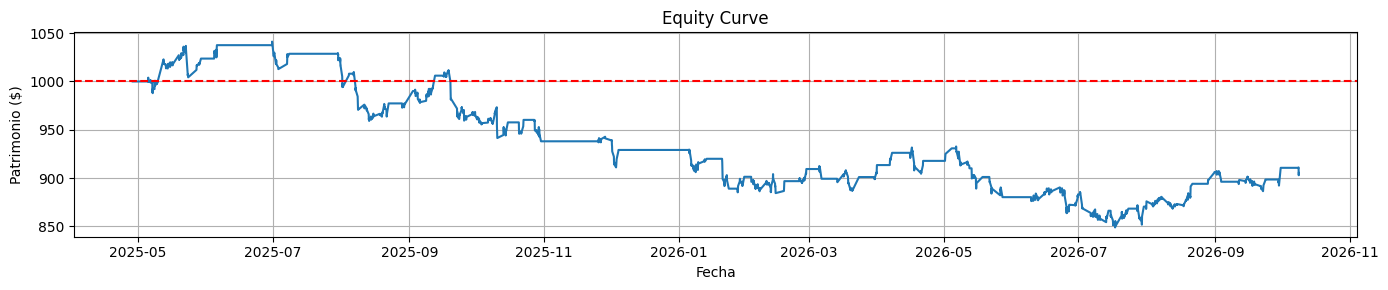

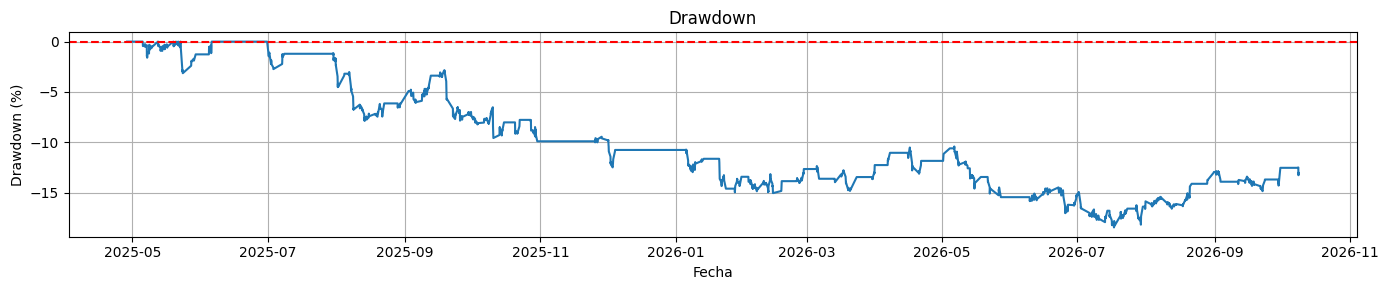

In [37]:
import matplotlib.pyplot as plt


dfpl = equity[equity["signal"] == "sign_rsi30"]
dfpl = dfpl.sort_values("time").copy()

dfpl["equity_peak"] = dfpl["equity"].cummax()

dfpl["drawdown"] = (
    dfpl["equity"] / dfpl["equity_peak"] - 1
)

fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(dfpl["time"], dfpl["equity"])

ax.set_title("Equity Curve")
ax.set_xlabel("Fecha")
ax.set_ylabel("Patrimonio ($)")
ax.grid(True)
ax.axhline(1000, linestyle = "--", color = "red")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(dfpl["time"], dfpl["drawdown"] * 100)

ax.set_title("Drawdown")
ax.set_xlabel("Fecha")
ax.set_ylabel("Drawdown (%)")
ax.grid(True)
ax.axhline(0, linestyle = "--", color = "red")

plt.tight_layout()
plt.show()

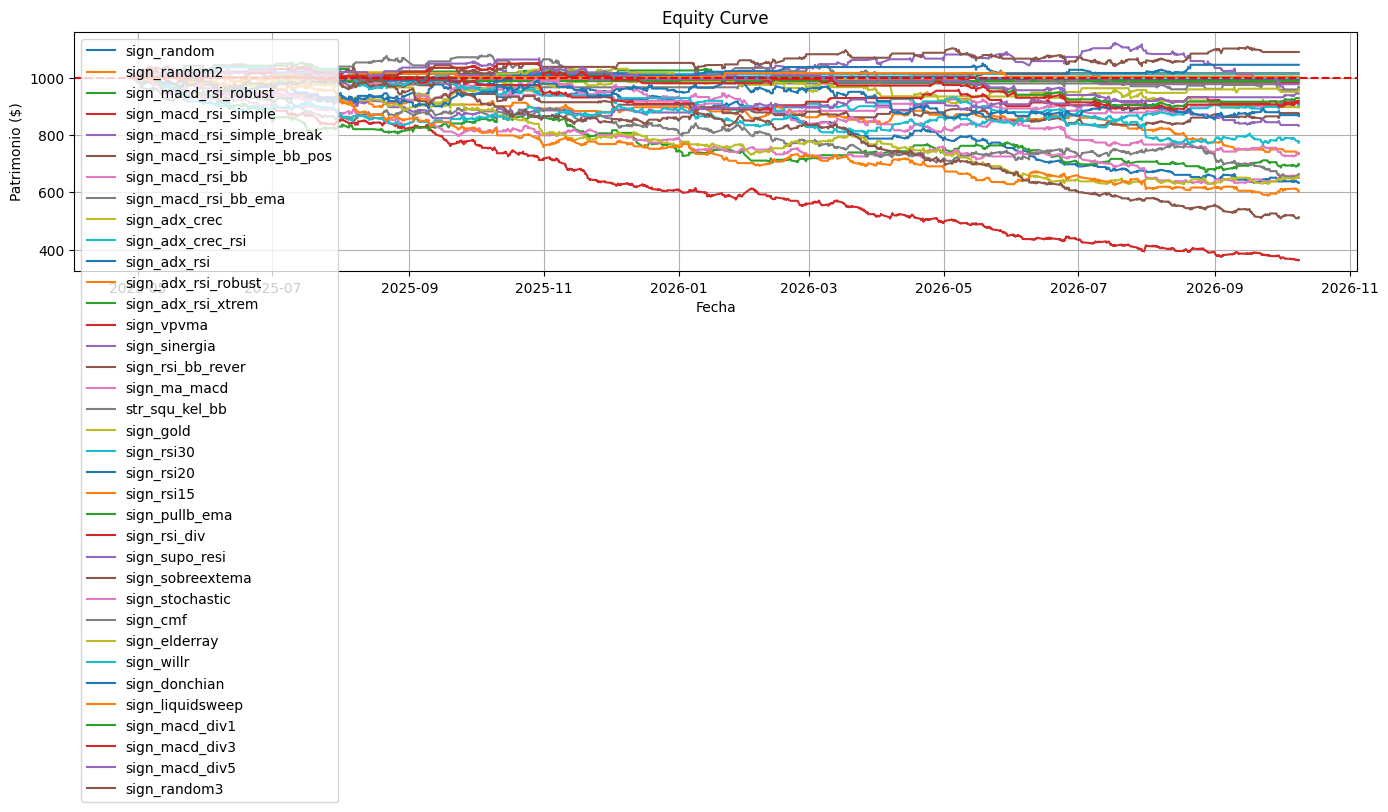

In [57]:
import matplotlib.pyplot as plt


dfpl = equity
dfpl = dfpl.sort_values("time").copy()

dfpl["equity_peak"] = dfpl["equity"].cummax()

dfpl["drawdown"] = (
    dfpl["equity"] / dfpl["equity_peak"] - 1
)

fig, ax = plt.subplots(figsize=(14, 6))

for sign in cols_sign:
    tmp = dfpl[dfpl["signal"] == sign]
    ax.plot(tmp["time"], tmp["equity"], label = sign)

ax.set_title("Equity Curve")
ax.set_xlabel("Fecha")
ax.set_ylabel("Patrimonio ($)")
ax.grid(True)
ax.axhline(1000, linestyle = "--", color = "red")

plt.legend()
plt.tight_layout()
plt.show()

In [39]:
qewe

NameError: name 'qewe' is not defined

In [ ]:
# Walk Forward + OOS

INITIAL_CAPITAL = 1000

RISK_PER_TRADE = 0.01
FEE_RATE = 0.0007
SLIPPAGE_PCT = 0.0005

ATR_SL = 2
MULTIPLIER_TP = 1.5

LEVERAGE = 100

USE_TRAILING_STOP = False
USE_BREAKEVEN = False

TRAILING_ATR_MULT = 1
TRAILING_ACTIVATION_R = 2.5
BREAKEVEN_TRIGGER_R = 3

CLOSE_ON_REVERSE = True

MIN_TRADES = 30


# ============================================================
# LISTA DE ESTRATEGIAS
# ============================================================

STRATEGY_COLUMNS = [
    "sign_macd_rsi_robust",
    "str_macd_rsi_simple",
    
]


# ============================================================
# MÉTRICAS DE UNA ESTRATEGIA
# ============================================================

def calculate_strategy_score(resume):

    """
    Convierte las métricas del backtest en un score.

    IMPORTANTE:
    No utilizamos solamente Return.

    Una estrategia que gana 100% pero tiene un drawdown
    enorme no necesariamente es mejor que una que gana 40%
    de forma estable.
    """

    if resume is None:
        return -np.inf

    trades = resume.get("trades", 0)

    if trades < MIN_TRADES:
        return -np.inf

    sharpe = resume.get("sharpe", 0)
    sortino = resume.get("sortino", 0)
    profit_factor = resume.get("profit_factor", 0)
    total_return = resume.get("total_return", 0)
    max_drawdown = resume.get("max_drawdown", 0)
    calmar = resume.get("calmar", 0)

    # --------------------------------------------------------
    # Protección contra NaN / infinitos
    # --------------------------------------------------------

    values = [
        sharpe,
        sortino,
        profit_factor,
        total_return,
        max_drawdown,
        calmar
    ]

    values = [
        0 if pd.isna(x) or np.isinf(x) else x
        for x in values
    ]

    sharpe, sortino, profit_factor, total_return, max_drawdown, calmar = values

    # --------------------------------------------------------
    # Penalización por drawdown
    # --------------------------------------------------------

    drawdown_penalty = abs(max_drawdown)

    # --------------------------------------------------------
    # Score
    # --------------------------------------------------------

    score = (
        0.25 * sharpe
        + 0.15 * sortino
        + 0.20 * profit_factor
        + 0.20 * total_return
        + 0.10 * calmar
        - 0.10 * drawdown_penalty
    )

    return score


# ============================================================
# NORMALIZAR RESULTADO DEL ENGINE
# ============================================================

def extract_metric(resume, key, default=0):

    if resume is None:
        return default

    value = resume.get(key, default)

    if value is None:
        return default

    if pd.isna(value):
        return default

    if np.isinf(value):
        return default

    return value


# ============================================================
# WALK FORWARD
# ============================================================

def walk_forward(
    df,
    strategy_columns,
    train_months=12,
    validation_months=3,
    step_months=3,
    top_n=5,
    min_trades=30
):

    """
    Walk Forward para seleccionar estrategias.

    Ejemplo:

    Train:
        enero 2024 - diciembre 2024

    Validation:
        enero 2025 - marzo 2025

    Luego:

    Train:
        abril 2024 - marzo 2025

    Validation:
        abril 2025 - junio 2025

    etc.

    La estrategia NO se selecciona mirando el futuro.

    """

    df = df.copy()

    # --------------------------------------------------------
    # Validaciones
    # --------------------------------------------------------

    if "time" not in df.columns:

        if isinstance(df.index, pd.DatetimeIndex):

            df = df.reset_index()

            if "time" not in df.columns:
                df = df.rename(columns={
                    df.columns[0]: "time"
                })

        else:
            raise ValueError(
                "El DataFrame debe tener columna 'time'"
            )

    df["time"] = pd.to_datetime(df["time"])

    df = df.sort_values("time").reset_index(drop=True)

    # --------------------------------------------------------
    # Fechas disponibles
    # --------------------------------------------------------

    min_date = df["time"].min()
    max_date = df["time"].max()

    print("=" * 70)
    print("WALK FORWARD")
    print("=" * 70)

    print("Inicio:", min_date)
    print("Fin:", max_date)

    # --------------------------------------------------------
    # Resultados
    # --------------------------------------------------------

    all_results = []

    selected_strategies = []

    # --------------------------------------------------------
    # Primer train
    # --------------------------------------------------------

    train_start = min_date

    while True:

        train_end = (
            train_start
            + pd.DateOffset(months=train_months)
        )

        validation_end = (
            train_end
            + pd.DateOffset(months=validation_months)
        )

        # ----------------------------------------------------
        # Si no existe suficiente futuro
        # ----------------------------------------------------

        if validation_end > max_date:

            break

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        train_mask = (
            (df["time"] >= train_start)
            &
            (df["time"] < train_end)
        )

        train_df = df.loc[train_mask].copy()

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        validation_mask = (
            (df["time"] >= train_end)
            &
            (df["time"] < validation_end)
        )

        validation_df = df.loc[
            validation_mask
        ].copy()

        print()
        print("-" * 70)

        print(
            f"TRAIN: {train_start.date()} -> "
            f"{train_end.date()}"
        )

        print(
            f"VALIDATION: {train_end.date()} -> "
            f"{validation_end.date()}"
        )

        # ----------------------------------------------------
        # Evaluar estrategias
        # ----------------------------------------------------

        fold_results = []

        for strategy in strategy_columns:

            if strategy not in df.columns:

                print(
                    f"[WARNING] No existe: {strategy}"
                )

                continue

            # ------------------------------------------------
            # TRAIN
            # ------------------------------------------------

            try:

                train_resume, train_state = engine(
                    train_df,
                    strategy
                )

            except Exception as e:

                print(
                    f"Error TRAIN {strategy}: {e}"
                )

                continue

            # ------------------------------------------------
            # VALIDATION
            # ------------------------------------------------

            try:

                validation_resume, validation_state = engine(
                    validation_df,
                    strategy
                )

            except Exception as e:

                print(
                    f"Error VALIDATION {strategy}: {e}"
                )

                continue

            # ------------------------------------------------
            # Número de trades
            # ------------------------------------------------

            train_trades = extract_metric(
                train_resume,
                "trades",
                0
            )

            validation_trades = extract_metric(
                validation_resume,
                "trades",
                0
            )

            if train_trades < min_trades:

                continue

            # ------------------------------------------------
            # Scores
            # ------------------------------------------------

            train_score = calculate_strategy_score(
                train_resume
            )

            validation_score = calculate_strategy_score(
                validation_resume
            )

            # ------------------------------------------------
            # Guardar resultado
            # ------------------------------------------------

            result = {

                "train_start": train_start,

                "train_end": train_end,

                "validation_start": train_end,

                "validation_end": validation_end,

                "strategy": strategy,

                "train_score": train_score,

                "validation_score": validation_score,

                "train_return": extract_metric(
                    train_resume,
                    "total_return"
                ),

                "validation_return": extract_metric(
                    validation_resume,
                    "total_return"
                ),

                "train_sharpe": extract_metric(
                    train_resume,
                    "sharpe"
                ),

                "validation_sharpe": extract_metric(
                    validation_resume,
                    "sharpe"
                ),

                "train_drawdown": extract_metric(
                    train_resume,
                    "max_drawdown"
                ),

                "validation_drawdown": extract_metric(
                    validation_resume,
                    "max_drawdown"
                ),

                "train_pf": extract_metric(
                    train_resume,
                    "profit_factor"
                ),

                "validation_pf": extract_metric(
                    validation_resume,
                    "profit_factor"
                ),

                "train_trades": train_trades,

                "validation_trades": validation_trades
            }

            fold_results.append(result)

        # ----------------------------------------------------
        # DataFrame del fold
        # ----------------------------------------------------

        fold_results_df = pd.DataFrame(
            fold_results
        )

        if len(fold_results_df) == 0:

            train_start = (
                train_start
                + pd.DateOffset(months=step_months)
            )

            continue

        # ----------------------------------------------------
        # Seleccionar TOP N
        #
        # IMPORTANTE:
        # La selección se hace con VALIDATION,
        # no con el futuro posterior.
        # ----------------------------------------------------

        fold_results_df = (
            fold_results_df
            .sort_values(
                "validation_score",
                ascending=False
            )
        )

        top_fold = fold_results_df.head(top_n).copy()

        # ----------------------------------------------------
        # Marcar seleccionadas
        # ----------------------------------------------------

        top_fold["selected"] = True

        all_results.append(
            fold_results_df
        )

        selected_strategies.append(
            top_fold
        )

        print()
        print("TOP ESTRATEGIAS")

        print(
            top_fold[
                [
                    "strategy",
                    "train_score",
                    "validation_score",
                    "validation_return",
                    "validation_sharpe",
                    "validation_drawdown",
                    "validation_pf",
                    "validation_trades"
                ]
            ].to_string(index=False)
        )

        # ----------------------------------------------------
        # Avanzar ventana
        # ----------------------------------------------------

        train_start = (
            train_start
            + pd.DateOffset(months=step_months)
        )

    # ========================================================
    # RESULTADOS
    # ========================================================

    if len(all_results) > 0:

        all_results = pd.concat(
            all_results,
            ignore_index=True
        )

    else:

        all_results = pd.DataFrame()

    if len(selected_strategies) > 0:

        selected_strategies = pd.concat(
            selected_strategies,
            ignore_index=True
        )

    else:

        selected_strategies = pd.DataFrame()

    return (
        all_results,
        selected_strategies
    )


# ============================================================
# CONSOLIDAR ESTRATEGIAS SELECCIONADAS
# ============================================================

def consolidate_selected_strategies(
    selected_df,
    top_n=5
):

    """
    Después del Walk Forward tenemos varias ventanas.

    Una estrategia puede aparecer muchas veces.

    Aquí calculamos:

        frecuencia
        score promedio
        validation return promedio
        validation Sharpe promedio

    y seleccionamos las más consistentes.
    """

    if selected_df.empty:

        return pd.DataFrame()

    summary = (
        selected_df
        .groupby("strategy")
        .agg(

            selections=(
                "strategy",
                "count"
            ),

            avg_validation_score=(
                "validation_score",
                "mean"
            ),

            median_validation_score=(
                "validation_score",
                "median"
            ),

            avg_validation_return=(
                "validation_return",
                "mean"
            ),

            avg_validation_sharpe=(
                "validation_sharpe",
                "mean"
            ),

            avg_validation_drawdown=(
                "validation_drawdown",
                "mean"
            ),

            avg_validation_pf=(
                "validation_pf",
                "mean"
            ),

            total_validation_trades=(
                "validation_trades",
                "sum"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Score de consistencia
    # --------------------------------------------------------

    summary["consistency_score"] = (

        0.35
        * summary["avg_validation_score"]

        +

        0.25
        * summary["median_validation_score"]

        +

        0.20
        * summary["avg_validation_sharpe"]

        +

        0.20
        * summary["avg_validation_pf"]

    )

    # --------------------------------------------------------
    # Primero estrategias que aparecen muchas veces
    # --------------------------------------------------------

    summary = summary.sort_values(
        [
            "selections",
            "consistency_score"
        ],
        ascending=False
    )

    return summary.head(top_n).reset_index(
        drop=True
    )


# ============================================================
# OOS
# ============================================================

def run_oos(
    df,
    selected_strategies,
    oos_start,
    strategy_columns=None
):

    """
    Ejecuta las estrategias seleccionadas sobre el período OOS.

    IMPORTANTE:

    OOS NO participa en:

        selección
        optimización
        ranking
        ajuste de parámetros

    Es solamente evaluación final.
    """

    df = df.copy()

    # --------------------------------------------------------
    # Validación de fecha
    # --------------------------------------------------------

    if "time" not in df.columns:

        if isinstance(df.index, pd.DatetimeIndex):

            df = df.reset_index()

            if "time" not in df.columns:

                df = df.rename(
                    columns={
                        df.columns[0]: "time"
                    }
                )

        else:

            raise ValueError(
                "El DataFrame debe tener columna 'time'"
            )

    df["time"] = pd.to_datetime(
        df["time"]
    )

    df = (
        df
        .sort_values("time")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Filtrar OOS
    # --------------------------------------------------------

    oos_df = df.loc[
        df["time"] >= pd.Timestamp(oos_start)
    ].copy()

    if oos_df.empty:

        raise ValueError(
            "El período OOS está vacío."
        )

    # --------------------------------------------------------
    # Estrategias
    # --------------------------------------------------------

    if isinstance(
        selected_strategies,
        pd.DataFrame
    ):

        strategies = (
            selected_strategies[
                "strategy"
            ]
            .drop_duplicates()
            .tolist()
        )

    else:

        strategies = list(
            selected_strategies
        )

    # --------------------------------------------------------
    # Resultados
    # --------------------------------------------------------

    results = []

    states = {}

    trades = {}

    print("=" * 70)
    print("OOS")
    print("=" * 70)

    print(
        "Inicio OOS:",
        oos_df["time"].min()
    )

    print(
        "Fin OOS:",
        oos_df["time"].max()
    )

    print(
        "Estrategias:",
        len(strategies)
    )

    # --------------------------------------------------------
    # Ejecutar cada estrategia
    # --------------------------------------------------------

    for strategy in strategies:

        if strategy not in oos_df.columns:

            print(
                f"[WARNING] No existe: {strategy}"
            )

            continue

        print()
        print(
            f"OOS -> {strategy}"
        )

        try:

            resume, state = engine(
                oos_df,
                strategy
            )

        except Exception as e:

            print(
                f"ERROR OOS {strategy}: {e}"
            )

            continue

        results.append(
            {
                "strategy": strategy,

                "oos_return": extract_metric(
                    resume,
                    "total_return"
                ),

                "oos_sharpe": extract_metric(
                    resume,
                    "sharpe"
                ),

                "oos_sortino": extract_metric(
                    resume,
                    "sortino"
                ),

                "oos_max_drawdown": extract_metric(
                    resume,
                    "max_drawdown"
                ),

                "oos_profit_factor": extract_metric(
                    resume,
                    "profit_factor"
                ),

                "oos_calmar": extract_metric(
                    resume,
                    "calmar"
                ),

                "oos_win_rate": extract_metric(
                    resume,
                    "win_rate"
                ),

                "oos_trades": extract_metric(
                    resume,
                    "trades"
                ),

                "oos_avg_r": extract_metric(
                    resume,
                    "avg_r"
                )
            }
        )

        states[strategy] = state

        # Si tu engine posteriormente devuelve trades:
        #
        # resume, state, trade_df = engine(...)
        #
        # entonces puedes guardar:
        #
        # trades[strategy] = trade_df

    # --------------------------------------------------------
    # DataFrame final
    # --------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )

    if not results_df.empty:

        results_df = (
            results_df
            .sort_values(
                "oos_sharpe",
                ascending=False
            )
            .reset_index(drop=True)
        )

    return (
        results_df,
        states,
        trades
    )


# ============================================================
# COMPARAR WALK FORWARD VS OOS
# ============================================================

def compare_wf_oos(
    wf_summary,
    oos_results
):

    if wf_summary.empty:
        return pd.DataFrame()

    if oos_results.empty:
        return pd.DataFrame()

    comparison = wf_summary.merge(
        oos_results,
        on="strategy",
        how="inner"
    )

    # --------------------------------------------------------
    # Degradación
    #
    # Ejemplo:
    #
    # validation Sharpe = 2
    # OOS Sharpe = 1
    #
    # degradación = 50%
    # --------------------------------------------------------

    comparison["return_degradation"] = (

        comparison["avg_validation_return"]
        - comparison["oos_return"]

    )

    comparison["sharpe_degradation"] = (

        comparison["avg_validation_sharpe"]
        - comparison["oos_sharpe"]

    )

    comparison["pf_degradation"] = (

        comparison["avg_validation_pf"]
        - comparison["oos_profit_factor"]

    )

    # --------------------------------------------------------
    # OOS positivo
    # --------------------------------------------------------

    comparison["oos_positive"] = (

        comparison["oos_return"] > 0

    )

    comparison["oos_sharpe_positive"] = (

        comparison["oos_sharpe"] > 0

    )

    comparison["oos_pf_positive"] = (

        comparison["oos_profit_factor"] > 1

    )

    return comparison